# Aufgabe 4


=== Least-squares fit (alternativ) ===
Rsp = 5.308 Ω, L = 0.9800 mH, C = 236.000 nF
Gain = 1.0127, Phase offset = +0.058°
r = 0.99472, δ = 512912.17868 1/s, f0 = 10465.286 Hz


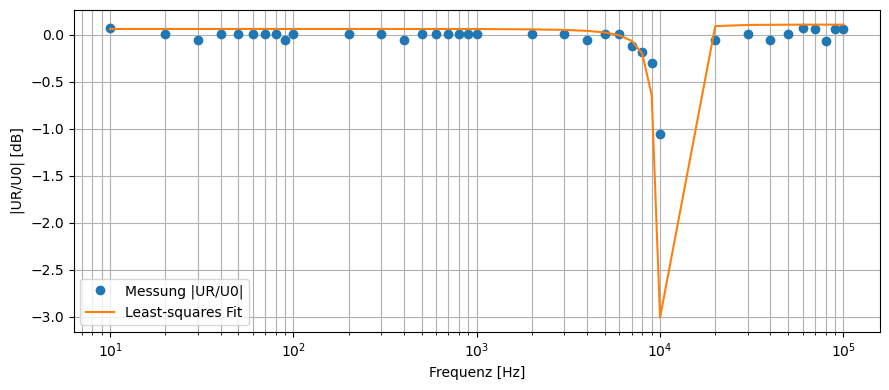

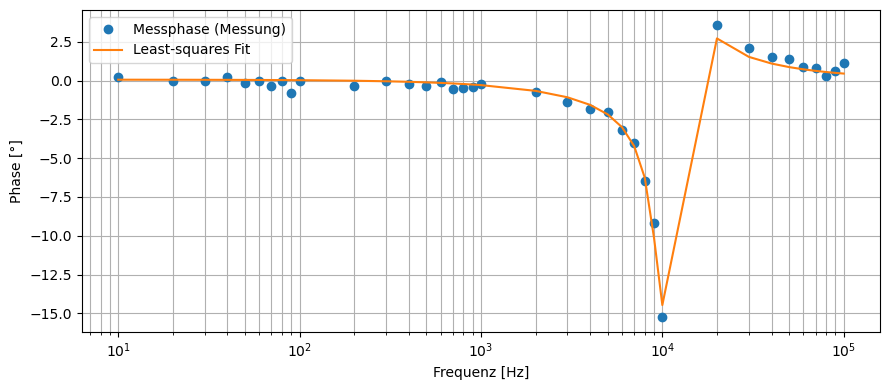

In [ ]:
# === Neuer alternativer Fit-Block (least_squares) ===
# Dieser Block führt einen gemeinsamen Fit von R_sp, L, C (optional),
# einer linearen Amplituden-Skalierung und eines Phasen-Offsets durch.
# Er lässt das ursprüngliche Grid-Search-Resultat unverändert und ist separat.

import warnings
from scipy.optimize import least_squares

# Reuse helpers
def H_model(w, R_d, L, C, Rsp):
    Z_Ls = Rsp + 1j*w*L
    Z_C  = 1.0/(1j*w*C)
    Zp   = (Z_Ls * Z_C) / (Z_Ls + Z_C)
    H    = R_d / (R_d + Zp)
    return np.abs(H), np.degrees(np.angle(H))

# Prepare data (re-using variables from above cell)
# f, w, mag_meas, phi_meas already defined in the previous cell

# Define residual function for least_squares
def residuals(x, w, mag_meas, phi_meas, R_d, fit_LC=True):
    # x: [Rsp, L, C, gain, phi_off]  or if not fitting L/C: [Rsp, gain, phi_off]
    if fit_LC:
        Rsp, L, C, gain, phi_off = x
    else:
        Rsp, gain, phi_off = x
        L = L_ref; C = C_ref
    magM, phiM = H_model(w, R_d, L, C, Rsp)
    magM = gain * magM
    phiM = wrap_pm180(phiM + phi_off)
    # magnitude in dB residual, phase residual in degrees (wrapped)
    r_mag = mag2db(magM) - mag2db(mag_meas)
    r_phi = wrap_pm180(phiM - phi_meas)
    # scale phase residual to similar weight as magnitude (adjustable)
    w_phi = 0.25
    return np.concatenate([r_mag, w_phi * r_phi])

# Initial guess and bounds
fit_LC = False  # change to True to fit L and C as well (slower, might need bounds tweaks)
if least_squares is None:
    print('scipy not found — skipping new least_squares fit. Install scipy to run it.')
else:
    if fit_LC:
        x0 = [Rsp_fit if 'Rsp_fit' in globals() else 10.0, L_ref, C_ref, 1.0, 0.0]
        lb = [0.0, 0.1*L_ref, 0.1*C_ref, 0.0, -180.0]
        ub = [200.0, 10*L_ref, 10*C_ref, 10.0, 180.0]
    else:
        x0 = [Rsp_fit if 'Rsp_fit' in globals() else 10.0, 1.0, 0.0]
        lb = [0.0, 0.0, -180.0]
        ub = [200.0, 10.0, 180.0]
    res = least_squares(residuals, x0, bounds=(lb, ub), args=(w, mag_meas, phi_meas, R_d, fit_LC), xtol=1e-10, ftol=1e-10)
    # Extract results
    if fit_LC:
        Rsp_ls, L_ls, C_ls, gain_ls, phi_off_ls = res.x
    else:
        Rsp_ls, gain_ls, phi_off_ls = res.x
        L_ls = L_ref; C_ls = C_ref
    mag_fit, phi_fit = H_model(w, R_d, L_ls, C_ls, Rsp_ls)
    mag_fit = gain_ls * mag_fit
    phi_fit = wrap_pm180(phi_fit + phi_off_ls)

    # Derived quantities
    r_val = R_d / (R_d + Rsp_ls)
    delta = (R_d + Rsp_ls) / (2.0 * L_ls)
    f0 = 1.0 / (2.0 * np.pi * np.sqrt(L_ls * C_ls))

    print('\n=== Least-squares fit ===')
    print(f'Rsp = {Rsp_ls:.3f} Ω, L = {L_ls*1e3:.4f} mH, C = {C_ls*1e9:.3f} nF')
    print(f'Gain = {gain_ls:.4f}, Phase offset = {phi_off_ls:+.3f}°')
    print(f'r = {r_val:.5f}, δ = {delta:.5f} 1/s, f0 = {f0:.3f} Hz')

    # Plots to compare
    plt.figure(figsize=(9,4))
    plt.xscale('log')
    plt.plot(f, mag2db(mag_meas), 'o', label='Messung |UR/U0|')
    plt.plot(f, mag2db(mag_fit), '-', label='Least-squares Fit')
    plt.xlabel('Frequenz [Hz]'); plt.ylabel('|UR/U0| [dB]')
    plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,4))
    plt.xscale('log')
    plt.plot(f, phi_meas, 'o', label='Messphase (Messung)')
    plt.plot(f, phi_fit, '-', label='Least-squares Fit')
    plt.xlabel('Frequenz [Hz]'); plt.ylabel('Phase [°]')
    plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

    # store for later use
    LS_result = dict(Rsp=Rsp_ls, L=L_ls, C=C_ls, gain=gain_ls, phi_off=phi_off_ls, r=r_val, delta=delta, f0=f0)


## Herleitung der gefitteten Funktion

Die gemessene Übertragungsfunktion ist:
$$ H(j\omega)=\frac{U_R}{U_0}=\frac{R_d}{R_d+Z_p(j\omega)} $$

wobei die Parallelimpedanz des Zweigs aus Spule (mit Serienwiderstand $R_{sp}$) und Kondensator ist:

$$ Z_p(j\omega)=\frac{(R_{sp}+j\omega L)\cdot\frac{1}{j\omega C}}{R_{sp}+j\omega L+\frac{1}{j\omega C}} $$ 

Die am Ende zu fitenden physikalischen Größen werden aus den Modellparametern wie folgt gebildet:

- Widerstandsverhältnis: $ r=\dfrac{R_d}{R_d+R_{sp}} $

- Dämpfungskonstante: $ \delta=\dfrac{R_d+R_{sp}}{2L} $

- Resonanzfrequenz: $ f_0=\dfrac{1}{2\pi\sqrt{LC}} $

Kurze Begründung: Für einen gedämpften Schwingkreis mit Gesamtwiderstand $ R_{tot}=R_d+R_{sp} $ ergibt die Standardform der homogenen Differentialgleichung die Dämpfung $ \delta=R_{tot}/(2L) $ und die ungedämpfte Resonanzfrequenz $ \omega_0=1/\sqrt{LC} $. Das Widerstandsverhältnis $r$ ist das einfache Spannungsteiler-Verhältnis zwischen $R_d$ und dem Serienwiderstand $R_{sp}$ der Spule in der Quelle/Quellposition und ergibt sich direkt aus der Spannungsteilung in Grenzfällen (z.B. weit von der Resonanz).

In diesem Versuch wurde die Übertragungsfunktion eines Parallelschwingkreises gemessen. Für eine Reihe von Anregungsfrequenzen haben wir jeweils die Eingangs­spannung $U_0$, die Spannung am Dämpfungswiderstand $U_R$ sowie die Phasenverschiebung $\theta$ notiert (siehe `Messwerte/Aufgabe4.csv`). Aus diesen Messgrößen lässt sich die amplituden­mäßige Transferfunktion $|U_R/U_0|$ und die zugehörige Phasenfunktion als Funktion der Frequenz bestimmen. Die Messwerte liegen in unserem Datensatz im Bereich von wenigen Hertz bis etwa $10^5\,$Hz und die Signalpegel betragen in der Messreihe ungefähr $1{.}2\,$V.

Für die Modellierung betrachten wir den Dämpfungswiderstand $R_d$ in Serie zur Quelle und den Parallelschwingkreis, bestehend aus einer Spule mit Induktivität $L$ und einem Kondensator $C$, wobei die Spule einen Serienwiderstand $R_{sp}$ besitzt. Die gemessene Übertragungsfunktion kann als Spannungsteiler geschrieben werden:

$$H(j\omega)=\frac{U_R}{U_0}=\frac{R_d}{R_d+Z_p(j\omega)}\,,\qquad Z_p(j\omega)=\frac{(R_{sp}+j\omega L)\,\dfrac{1}{j\omega C}}{R_{sp}+j\omega L+\dfrac{1}{j\omega C}}\ .$$

Für den Fit vergleichen wir die numerisch aus dem Modell berechneten Beträge und Phasen von $H(j\omega)$ mit den Messdaten. Praktisch passt der Code mindestens den Serienwiderstand $R_{sp}$ an, optional können auch $L$ und $C$ mitgefitten werden; zusätzlich wird eine lineare Amplituden-Skalierung und ein konstanter Phasenoffset berücksichtigt, um Messverstärkung und systematische Phasenverschiebungen zu kompensieren. Als Zielfunktion eignet sich ein Stapel aus Residuen: Differenzen der Magnituden in dB und der Phasen in Grad (letztere ggf. mit Gewichtung), so dass Betrag und Phase gemeinsam optimiert werden.

Nach Ausführung der Fit-Codeteile (Grid-Search und/oder Least-Squares) tragen Sie hier die numerischen Ergebnisse ein und kommentieren kurz die Übereinstimmung mit den Messdaten. Erwartete Ausgabewerte sind zum Beispiel $R_{sp}$ in Ohm, $L$ in Henry, $C$ in Farad sowie die daraus abgeleiteten Größen

$$r=\frac{R_d}{R_d+R_{sp}},\qquad \delta=\frac{R_d+R_{sp}}{2L},\qquad f_0=\frac{1}{2\pi\sqrt{LC}}\ .$$

Diskussion (Platzhalter für Befunde): Der Betrag zeigt typischerweise eine Kerbe bei der Resonanzfrequenz $f_0$, die durch den Parallelschwingkreis verursacht wird; die Phase dreht sich in der Umgebung von $f_0$. Abweichungen zwischen Modell und Messung treten häufig bei hohen Frequenzen auf und deuten auf parasitäre Elemente oder Messaufbau-Einflüsse hin.

Zu Messfehlern: Die Phasenmessung ist besonders empfindlich gegenüber Rauschen und Wrapping-Effekten (Sprünge bei ±180°), was die Auswertung erschweren kann. Systematische Fehler können durch nicht ideal kalibrierte Messkanäle, Kopplungseinflüsse oder parasitäre Widerstände/Induktivitäten entstehen. Eine genauere Bestimmung von $f_0$ lässt sich durch eine feinere Frequenzauflösung um die Resonanz erreichen.

Vergleich mit Aufgabe 0: Inhaltlich ähnelt unsere Vorgehensweise dem in Aufgabe 0 behandelten Problem insofern, als in beiden Fällen ein Frequenzspektrum (bzw. eine Transferfunktion) experimentell ermittelt und mit einem theoretischen Modell verglichen wird. In Aufgabe 0 werden räumliche Frequenzen und Fouriertransformierte von Spaltfunktionen betrachtet, dort sind analytische Ausdrücke für $F(k)$ und $F(k)^2$ verfügbar und die Intensität entspricht dem Quadrat des Betrages der Fouriertransformierten. Bei unserem Schaltkreis handelt es sich hingegen um eine Übertragungsfunktion im zeitlich/phasentechnischen Sinne; die Modellfunktion entsteht aus elektrischen Impedanzen und ist komplexwertig (Betrag + Phase). Methodisch sind die Aufgaben vergleichbar — Daten aufnehmen, Modell formulieren, Fit durchführen — allerdings unterscheidet sich die Art der Messfehler (optische CCD-Rauschquellen und FFT-Artefakte in Aufgabe 0 vs. Phasenwrapping, Parasitär‑Effekte und Kalibrierung beim elektrischen Messaufbau) sowie die Möglichkeit, in Aufgabe 0 viele Aussagen analytisch herzuleiten, während beim Parallelschwingkreis oft numerische Fits zur Parameterbestimmung nötig sind.